In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import IN, LIF, PSP

from sango.backend import SimBrian

In [2]:
class Input(Network):
    def __init__(self, spike_times):
        super().__init__()
        self.spike_times = spike_times # n x t

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        
        return

In [3]:
class GraphSSSP(Network):
    def __init__(self, graph, source_node=0, node_map=dict()):
        super().__init__()
        self.graph = graph
        self.source_node = source_node
        self.node_map = node_map # updated through side effects
        self.input = NodePort(1)

    def build(self):
        # Node names to indexes
        for n, node in enumerate(self.graph.nodes()):
            self.node_map[node] = n
        
        # Main graph nodes
        self.g = NodeGroup(LIF(threshold=0.9, leak=0.0), self.graph.number_of_nodes())
        
        # Self connnections (inhibitory)
        self.gi = EdgeGroup(self.g, self.g, PSP(weight=-10000.0),
                            edges=[(i,i) for i in range(self.g.size)])
        
        # Neighbor connections (causes direct neighbors to spike)
        neighbor_edges = [(self.node_map[s], self.node_map[t])for s,t in self.graph.edges()]
        self.ge = EdgeGroup(self.g, self.g, PSP(delay=2.0),
                            edges=neighbor_edges)
        # Convert weights to delays if provided (default weight is 1.0)
        for s, t, data in self.graph.edges(data=True):
            if 'weight' in data:
                self.ge[(s,t)].delay = 2 * data['weight']
        
        # Input to main
        self.ig = EdgeGroup(self.input, self.g, PSP(), edges=[(0, self.source_node)])
        
        return

In [4]:
# Showing off network inheritance
class GraphSSSPParent(GraphSSSP):
    def __init__(self, graph, source_node=0, node_map=dict(), parent_map=dict()):
        super().__init__(graph, source_node, node_map)
        self.parent_map = parent_map # provide external dict to modify

    def build(self):
        # Default SSSP build
        super().build()
        
        # Reference names to indexes
        forward_edges = []
        backward_edges = []
        for n, (source, target) in enumerate(self.graph.edges()):
            self.parent_map[(source, target)] = n
            forward_edges.append((self.node_map[source], n))
            backward_edges.append((self.node_map[target], n))
        
        # Reference nodes
        self.p = NodeGroup(LIF(threshold=0.9, leak=0.0), self.graph.number_of_edges())

        # Forward connections (excitatory)
        self.pe = EdgeGroup(self.g, self.p, PSP(), edges=forward_edges)
        
        # Back connnections (inhibitory)
        self.pi = EdgeGroup(self.g, self.p, PSP(weight=-10000.0), edges=backward_edges)
        
        return

In [5]:
import random
from networkx.generators.random_graphs import fast_gnp_random_graph

def create_graph(size, p, seed):
    G = fast_gnp_random_graph(size, p, seed=seed, directed=True)
    return G

def create_weighted_graph(size, p, seed):
    random.seed(seed)
    G = fast_gnp_random_graph(size, p, seed=seed, directed=True)
    for u, v in G.edges():
        G.edges[u, v]["weight"] = random.randint(1, 10)
    return G

In [6]:
# Simple test graph problem
input_vec = [[0]]
source_node = 1
test_graph = create_weighted_graph(15, 0.3, 3)

# Some information that is updated through side effects
# The recursive build process does not return anything,
# so we pass these dictionary objects by reference
node_map = dict()
parent_map = dict()

# Construct the SSSP network
net = Network()
net.i = Input(spike_times=input_vec)
net.s = GraphSSSPParent(test_graph, source_node=source_node,
                        node_map=node_map, parent_map=parent_map)
net.connect(net.i.spikegen, net.s.input)

net.build()

info: adding network i
info: adding network s
info: building network i
info: building network s
info: linking port s.input
info: flattening network topology


In [7]:
net.s.ge.delay

array([ 8., 20., 18.,  6., 12., 20., 16., 20.,  4., 20.,  2., 16., 10.,
       18.,  8.,  8., 16., 18., 18., 16., 14.,  6.,  8.,  6., 18., 14.,
        2.,  4.,  6., 20.,  2., 10.,  2., 10., 16., 20., 14., 14., 14.,
       20., 16.,  6., 12.,  4.,  2.,  6., 16.,  8., 10., 14., 10., 14.,
       18., 14., 20., 12.])

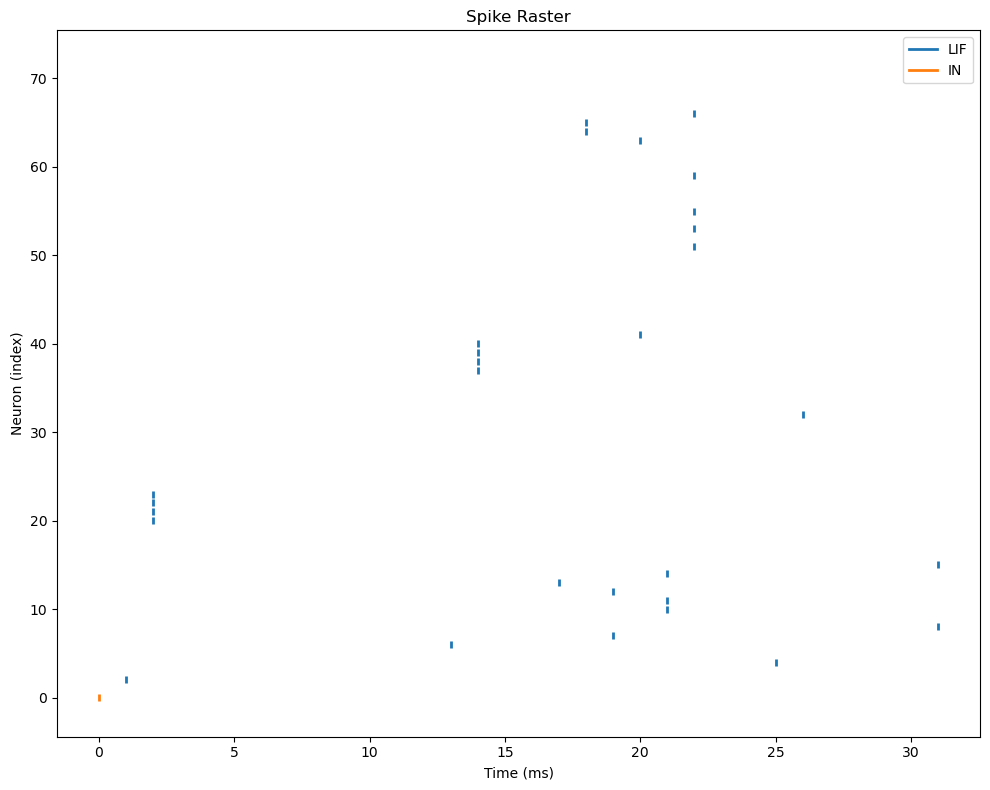

In [8]:
# Simulating it in Brian
sim = SimBrian(net)
sim.compile()
sim.run((test_graph.number_of_nodes()+1)*2)

sim.plot_spikes(figsize=(10,8), linewidths=2.0)